In [5]:
import os

os.listdir()

['AI BOOTCAMP(1).ipynb',
 'Untitled1.ipynb',
 'Untitled3.ipynb',
 'assignment_day_2.ipynb',
 'student_performance - student_performance (1).csv',
 'student_performance.ipynb',
 'r.ipynb',
 'Lorenz.ipynb',
 'Mandelbrot.ipynb',
 'sqlite.ipynb',
 'cpp.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp-tiny-ray-tracer.ipynb',
 'Intro.ipynb']

In [6]:
import pandas as pd

df = pd.read_csv("student_performance - student_performance (1).csv")

df

,student_id,study_hours,attendance,assignments,result
0,1,1.0,58,3,0
1,2,1.5,62,5,0
2,3,2.0,65,6,0
3,4,2.5,68,7,1
4,5,3.0,72,7,1
5,6,3.5,75,8,1
6,7,4.0,78,9,1
7,8,4.5,82,9,1
8,9,5.0,85,10,1
9,10,0.5,45,2,0


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

df = pd.read_csv("student_performance - student_performance (1).csv")

df.head()

df.groupby("result")[["study_hours", "attendance", "assignments"]].mean()

Environment ready!
NumPy: 2.4.3
pandas: 3.0.2
scikit-learn: 1.8.0


,study_hours,attendance,assignments
result,,,
0,1.633333,65.037037,5.296296
1,3.824242,76.060606,8.393939


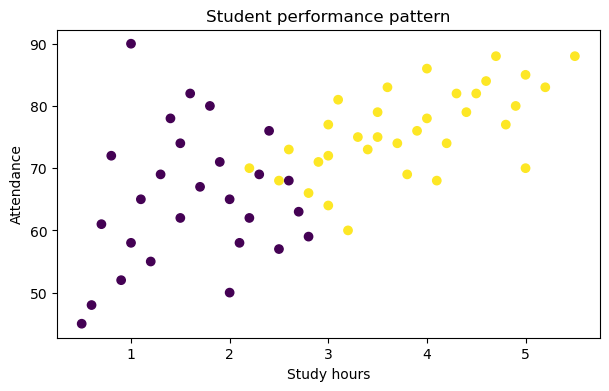

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


In [8]:
plt.figure(figsize=(7,4))

plt.scatter(
    df["study_hours"],
    df["attendance"],
    c=df["result"]
)

plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()


X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]


print("X shape:", X.shape)
print("y shape:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_train, y_train)

print("Model trained!")

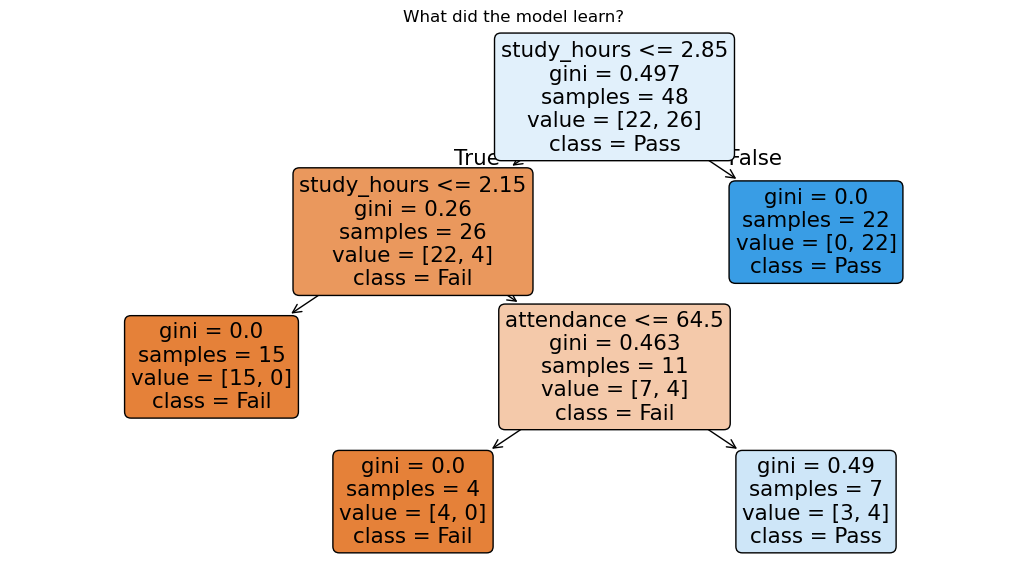

In [9]:
plt.figure(figsize=(13, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)

plt.title("What did the model learn?")
plt.show()

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# =====================================================================
# STEP 1: Prepare Sample Data (In-Memory Dataset)
# =====================================================================
# We define simple email subjects and label them as 0 (Ham/Safe) or 1 (Spam)
emails = [
    "Meeting schedule for tomorrow project review",  # Safe (0)
    "WIN FREE CASH NOW! CLICK HERE!",  # Spam (1)
    "Please send the engineering lab report by Friday",  # Safe (0)
    "Claim your free prize money today",  # Spam (1)
    "Urgent account verification required",  # Safe (0)
    "CONGRATULATIONS! You won a brand new car",  # Spam (1)
]

labels = [0, 1, 0, 1, 0, 1]  # 0 = Normal Email, 1 = Spam Email

# =====================================================================
# STEP 2: Feature Extraction (Convert Text to Numbers)
# =====================================================================
# Machine Learning algorithms work on numbers, not raw text.
# CountVectorizer counts how many times each word appears in each email.
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# =====================================================================
# STEP 3: Train the Machine Learning Model
# =====================================================================
# We use Naive Bayes, a classic, fast algorithm for text classification.
model = MultinomialNB()
model.fit(X, labels)

print("--- Model Training Complete! ---\n")

# =====================================================================
# STEP 4: Test the Model on Unseen Email Subjects
# =====================================================================
new_emails = [
    "Submit your lab assignment tomorrow",  # Expected: Safe
    "Win a free prize and cash bonus now",  # Expected: Spam
]

# Convert new text to the exact same numerical format
X_new = vectorizer.transform(new_emails)

# Make predictions
predictions = model.predict(X_new)

# Display Results
for email, pred in zip(new_emails, predictions):
    status = "SPAM 🚨" if pred == 1 else "SAFE / NORMAL 🟢"
    print(f"Email   : '{email}'")
    print(f"Result  : {status}\n")

--- Model Training Complete! ---

Email   : 'Submit your lab assignment tomorrow'
Result  : SAFE / NORMAL 🟢

Email   : 'Win a free prize and cash bonus now'
Result  : SPAM 🚨

